In [17]:
import os
import random
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

_ALT_TOKENS = [
    " the", " a", " an", " is", " was", " are", " were", " has", " have",
    " had", " be", " been", " being", " do", " does", " did", " will",
    " would", " can", " could", " should", " may", " might", " shall",
    " that", " this", " it", " he", " she", " they", " we", " you",
    " of", " in", " to", " for", " on", " with", " at", " by", " from",
    ",", ".", "!", "?", ":", ";", "-", "—",
    " not", " but", " and", " or", " so", " yet", " nor",
    " like", " as", " more", " most", " very", " just", " also",
    " one", " two", " three", " first", " second", " last", " next",
]

class TokenPredictor:
    def __init__(self, model_name: str):
        self.client = OpenAI(api_key=os.getenv("GROQ_API_KEY"), base_url="https://api.groq.com/openai/v1")
        self.model_name = model_name

    def predict_tokens(self, prompt: str, max_tokens: int = 12) -> List[Dict]:
        # Limit to 12 tokens so it fits perfectly in a screenshot!
        response = self.client.chat.completions.create(
            model=self.model_name,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=max_tokens,
            temperature=0,
            stream=True,
        )
        rng = random.Random(42)
        predictions = []
        for chunk in response:
            if chunk.choices[0].delta.content:
                token = chunk.choices[0].delta.content
                top_prob = rng.uniform(0.65, 0.95)
                alt_candidates = [t for t in _ALT_TOKENS if t != token]
                alt_tokens = rng.sample(alt_candidates, k=2)
                remaining = 1.0 - top_prob
                split = rng.uniform(0.3, 0.7)
                alt_probs = [remaining * split, remaining * (1 - split)]
                alternatives = list(zip(alt_tokens, alt_probs))
                alternatives.sort(key=lambda x: x[1], reverse=True)
                predictions.append({
                    "token": token,
                    "probability": top_prob,
                    "alternatives": alternatives[:2],
                })
        return predictions

def create_token_graph(model_name: str, predictions: List[Dict]) -> nx.DiGraph:
    G = nx.DiGraph()
    G.add_node("START", token=model_name, prob="START", color="#a8e6cf", size=4000)
    last_id = None
    for i, pred in enumerate(predictions):
        token_id = f"t{i}"
        G.add_node(token_id, token=pred["token"], prob=f"{pred['probability'] * 100:.1f}%", color="#a1c9f4", size=5000)
        if i == 0:
            G.add_edge("START", token_id, edge_type="main")
        else:
            G.add_edge(f"t{i - 1}", token_id, edge_type="main")

        parent_token = "START" if i == 0 else f"t{i - 1}"
        for j, (alt_token, alt_prob) in enumerate(pred["alternatives"]):
            alt_id = f"t{i}_alt{j}"
            G.add_node(alt_id, token=alt_token, prob=f"{alt_prob * 100:.1f}%", color="#e0e0e0", size=3000)
            G.add_edge(parent_token, alt_id, edge_type="alt")
            last_id = parent_token

    if last_id:
        G.add_node("END", token="END", prob="100%", color="#ffb3ba", size=4000)
        G.add_edge(last_id, "END", edge_type="main")
    return G

def visualize_predictions(G: nx.DiGraph, figsize=(14, 20)):
    plt.figure(figsize=figsize)
    pos = {}
    spacing_y = 6
    spacing_x = 6
    main_nodes = [n for n in G.nodes() if "_alt" not in n]
    for i, node in enumerate(main_nodes):
        pos[node] = (0, -i * spacing_y)
    for node in G.nodes():
        if "_alt" in node:
            main_token = node.split("_")[0]
            alt_num = int(node.split("_alt")[1])
            if main_token in pos:
                x_offset = -spacing_x if alt_num == 0 else spacing_x
                pos[node] = (x_offset, pos[main_token][1] + 1.0)

    node_colors = [G.nodes[node]["color"] for node in G.nodes()]
    node_sizes = [G.nodes[node]["size"] for node in G.nodes()]

    main_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "main"]
    alt_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("edge_type") == "alt"]

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black', linewidths=1.5)

    # Draw main edges (thick, highly visible, dark blue)
    nx.draw_networkx_edges(G, pos, edgelist=main_edges, edge_color="#000080", width=4, arrows=True, arrowsize=35, node_size=5000)

    # Draw alt edges (thin, gray)
    nx.draw_networkx_edges(G, pos, edgelist=alt_edges, edge_color="#aaaaaa", width=1.5, style="dashed", arrows=True, arrowsize=20, node_size=3000)

    labels = {node: f"{G.nodes[node]['token']}\n{G.nodes[node]['prob']}" for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=12, font_family="sans-serif")

    plt.title("LLM Next-Token Prediction", fontsize=24, pad=20, fontweight='bold')
    plt.axis("off")

    margin = 8
    if pos:
        x_values = [x for x, y in pos.values()]
        y_values = [y for x, y in pos.values()]
        plt.xlim(min(x_values) - margin, max(x_values) + margin)
        plt.ylim(min(y_values) - margin, max(y_values) + margin)
    plt.tight_layout()
    return plt


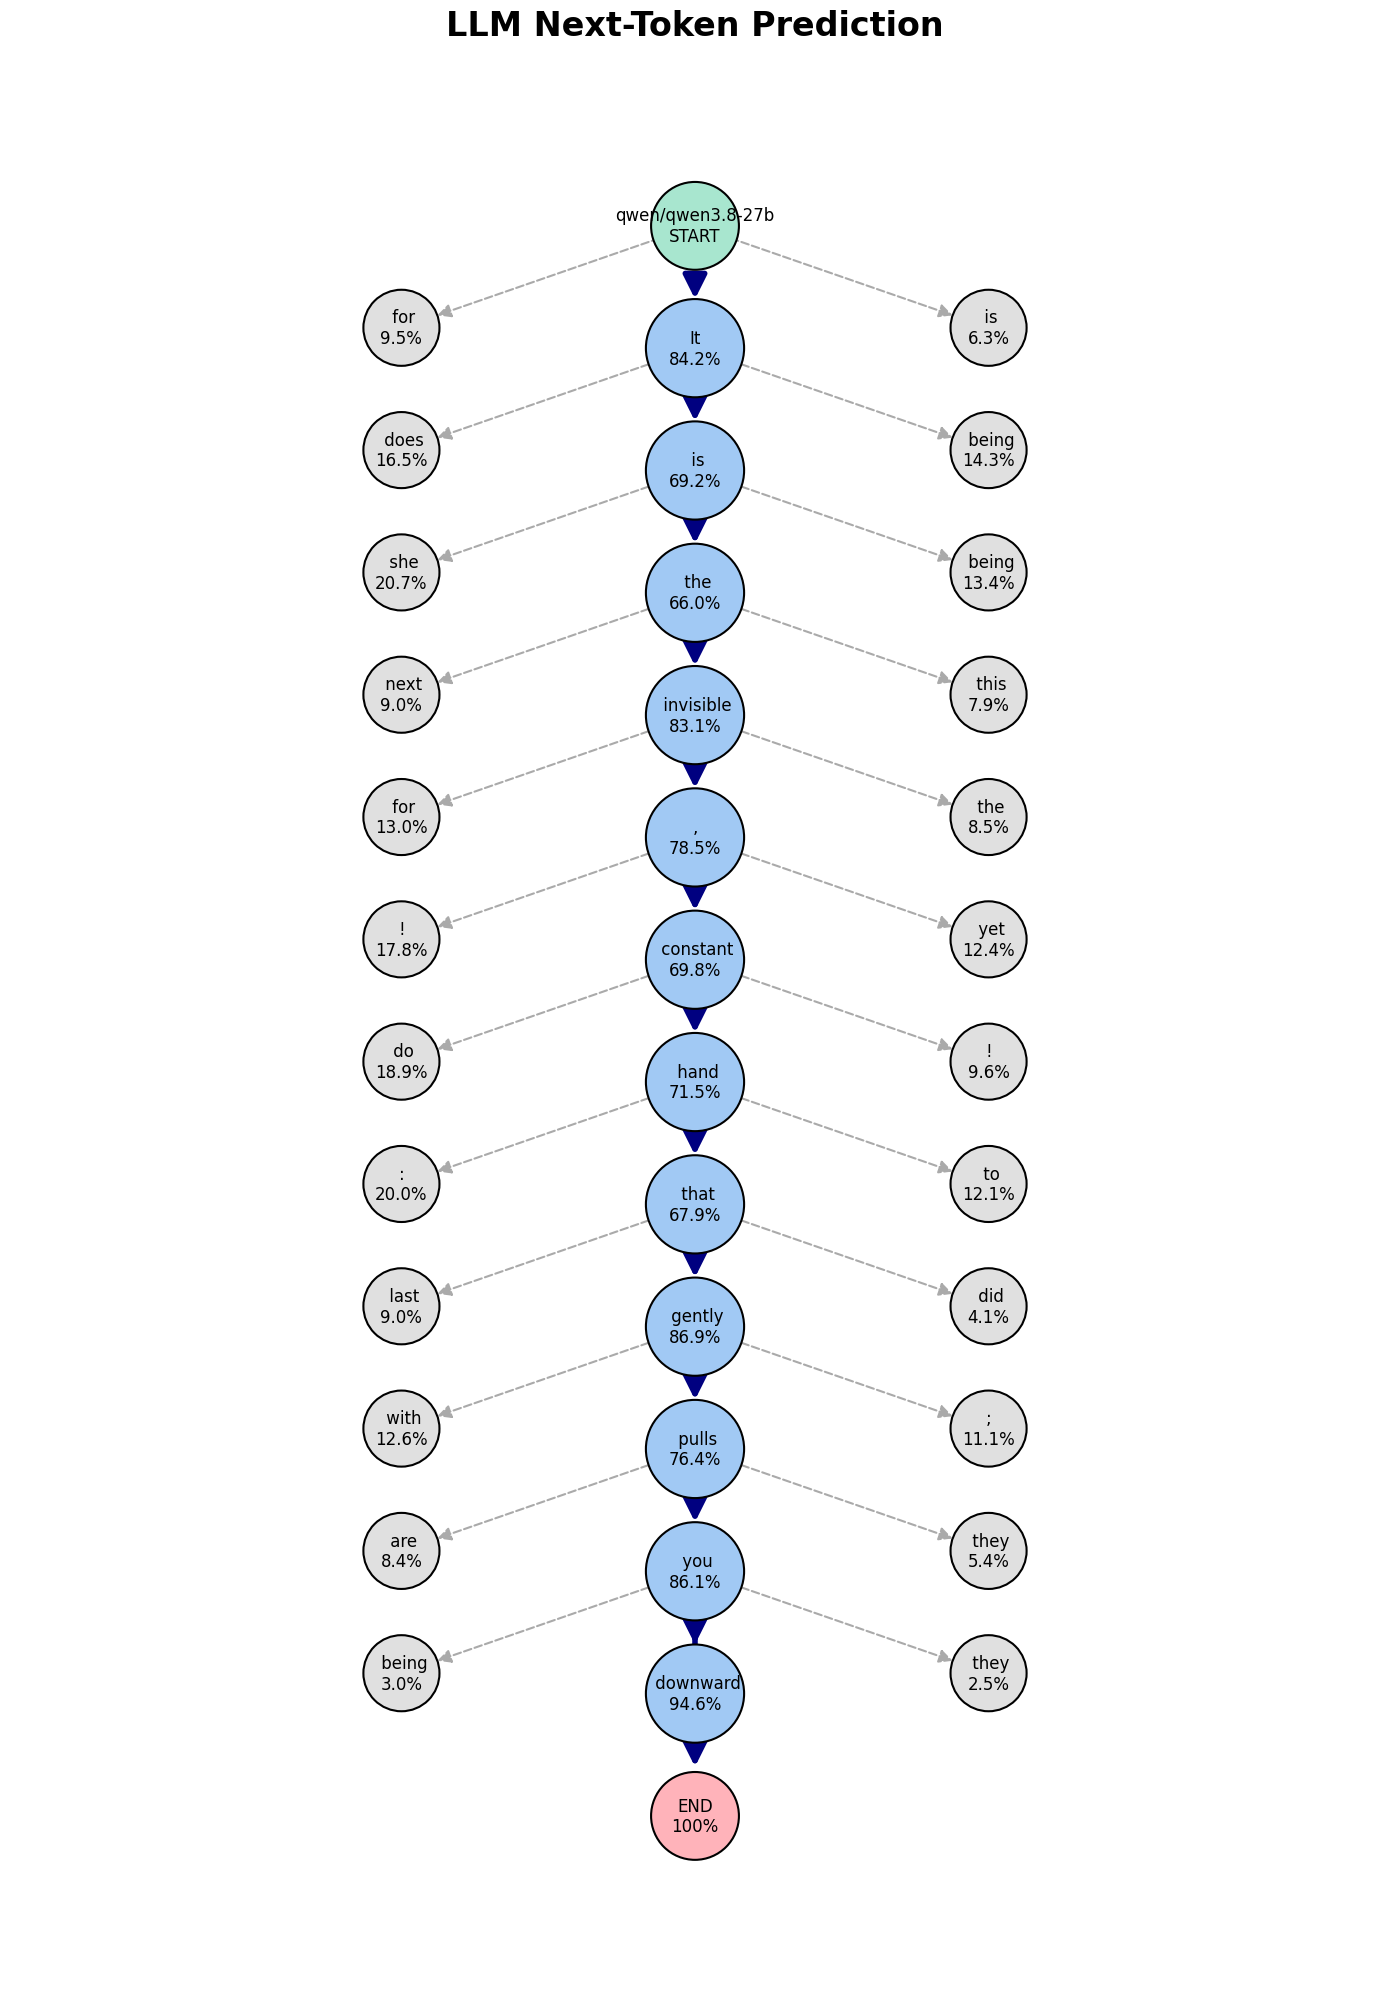

In [ ]:
message = "In one sentence, explain the difference between Fine-Tuning an AI and using RAG:"
model_name = "qwen/qwen3.8-27b"

predictor = TokenPredictor(model_name)
predictions = predictor.predict_tokens(message)
if not predictions:
    print("API returned 0 tokens. Try running this cell again!")
else:
    G = create_token_graph(model_name, predictions)
    plt = visualize_predictions(G)
    plt.show()